In [ ]:
### 階層的クラスタリング
#### 集計データを読み込み、階層的クラスタリングを行い、図示化する。

In [1]:
# ============================================================
# 階層的クラスタリング + bi-cluster ヒートマップ（完全版・修正版）
# 第1列をラベルとして使用（対応分析と同じ）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import to_hex

# ------------------------------------------------------------
# 1. パラメータ設定
# ------------------------------------------------------------
n_clusters = 3                     # 行クラスタ数
max_columns = 30                 # ★ 先頭から何列使うか（None なら全列）

# ▼距離の測度（metric）一覧
# "euclidean", "cityblock" or "manhattan", "cosine", "correlation", "chebyshev", "hamming", "jaccard", "minkowski", "canberra", 
# "mahalanobis",  "seuclidean"(標準ユークリッド距離),　"sqeuclidean", "braycurtis"(Bray-Curtis dist),
# "dice", "kulsinski", "rogerstanimoto", "russellrao",  "sokalmichener", "sokalsneath", "yule"
# カテゴリかるデータ

# ▼クラスタリング方法（method / linkage）一覧
# "single", "complete", "average", "ward", "weighted", "centroid", "median"

# 行クラスタリング設定
row_linkage_method = "ward"      # ★ Ward ではなく average を使う
row_distance_metric = "euclidean"

# 列クラスタリング設定
col_linkage_method = "average"
col_distance_metric = "canberra"

# ------------------------------------------------------------
# 2. データ読み込み
# ------------------------------------------------------------
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"

d1 = pd.read_csv(path, encoding='shift-jis')
# d1 を実行すると読み込んだデータがすべて表示される。
# データd1のヘットの部分を表示

# ------------------------------------------------------------
# 3. 第1列をラベルとして使用（対応分析と同じ）
# ------------------------------------------------------------
X.index = d1.iloc[:, 0]
X = d1.iloc[:, 1:]

# --- 行単位の相対頻度 ---
X_numeric = X.div(X.sum(axis=1), axis=0)

# ------------------------------------------------------------
# 4. 列数が多い場合 → 先頭 max_columns 列だけ使用（★ 修正ポイント）
# ------------------------------------------------------------
if max_columns is not None and X_numeric.shape[1] > max_columns:
    X_numeric = X_numeric.iloc[:, :max_columns]


# ------------------------------------------------------------
# 5. 標準化（行クラスタリング用）
# ------------------------------------------------------------
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_numeric)

# ------------------------------------------------------------
# 6. 行クラスタリング
# ------------------------------------------------------------
Z = linkage(X_numeric, method=row_linkage_method, metric=row_distance_metric)

cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
label_to_cluster = dict(zip(X.index, cluster_labels))

unique_clusters = np.unique(cluster_labels)
palette = seaborn_palette = sns.color_palette("tab10", len(unique_clusters))
cluster_color_map = {cid: to_hex(col) for cid, col in zip(unique_clusters, seaborn_palette)}

# ------------------------------------------------------------
# 7. 内部ノードにもクラスタIDを割り当てる
# ------------------------------------------------------------
node_cluster = {}
n_samples = len(X.index)

for i, lbl in enumerate(X.index):
    node_cluster[i] = label_to_cluster[lbl]

for i, (c1, c2, dist, cnt) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    node_id = n_samples + i
    if node_cluster[c1] == node_cluster[c2]:
        node_cluster[node_id] = node_cluster[c1]
    else:
        node_cluster[node_id] = 0

# ------------------------------------------------------------
# 8. 枝の色をクラスタIDに応じて返す関数
# ------------------------------------------------------------
def branch_color_func(node_id: int) -> str:
    cid = node_cluster[node_id]
    if cid == 0:
        return "black"
    return cluster_color_map[cid]

# ------------------------------------------------------------
# 9. クラスタ境界の高さ（cut line）
# ------------------------------------------------------------
threshold = Z[-(n_clusters - 1), 2]

# ------------------------------------------------------------
# 10. 樹形図の描画（枝＋ラベル色）
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ddata = dendrogram(
    Z,
    labels=X.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=branch_color_func,
)

ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    text = lbl.get_text()
    cid = label_to_cluster[text]
    lbl.set_color(cluster_color_map[cid])

plt.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.2)

plt.title(f"階層的クラスタリング樹形図（n_clusters = {n_clusters}）")
plt.xlabel("ドキュメント")
plt.ylabel("距離")
plt.tight_layout()
plt.show()

# ============================================================
# 11. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

# ============================================================
# 11. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

row_colors = [cluster_color_map[label_to_cluster[idx]] for idx in X.index]

g = sns.clustermap(
    X_numeric,
    method=row_linkage_method,
    metric=row_distance_metric,
    row_cluster=True,
    col_cluster=True,
    col_linkage=linkage(X_numeric.T, method=col_linkage_method, metric=col_distance_metric),
    row_colors=row_colors,
    cmap="viridis",
    figsize=(10, 10)
)

# ★ ここを 45 度に変更
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45)

# 行ラベルはそのまま（0 度）
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle("Bi-cluster ヒートマップ", y=1.02)
plt.show()


NameError: name 'X' is not defined

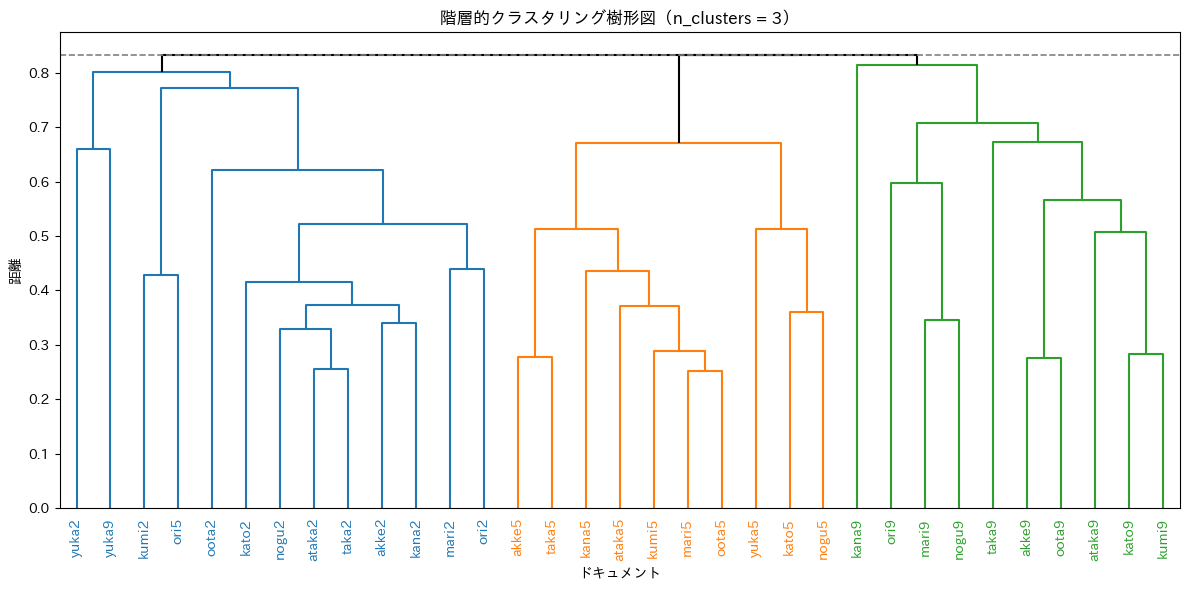

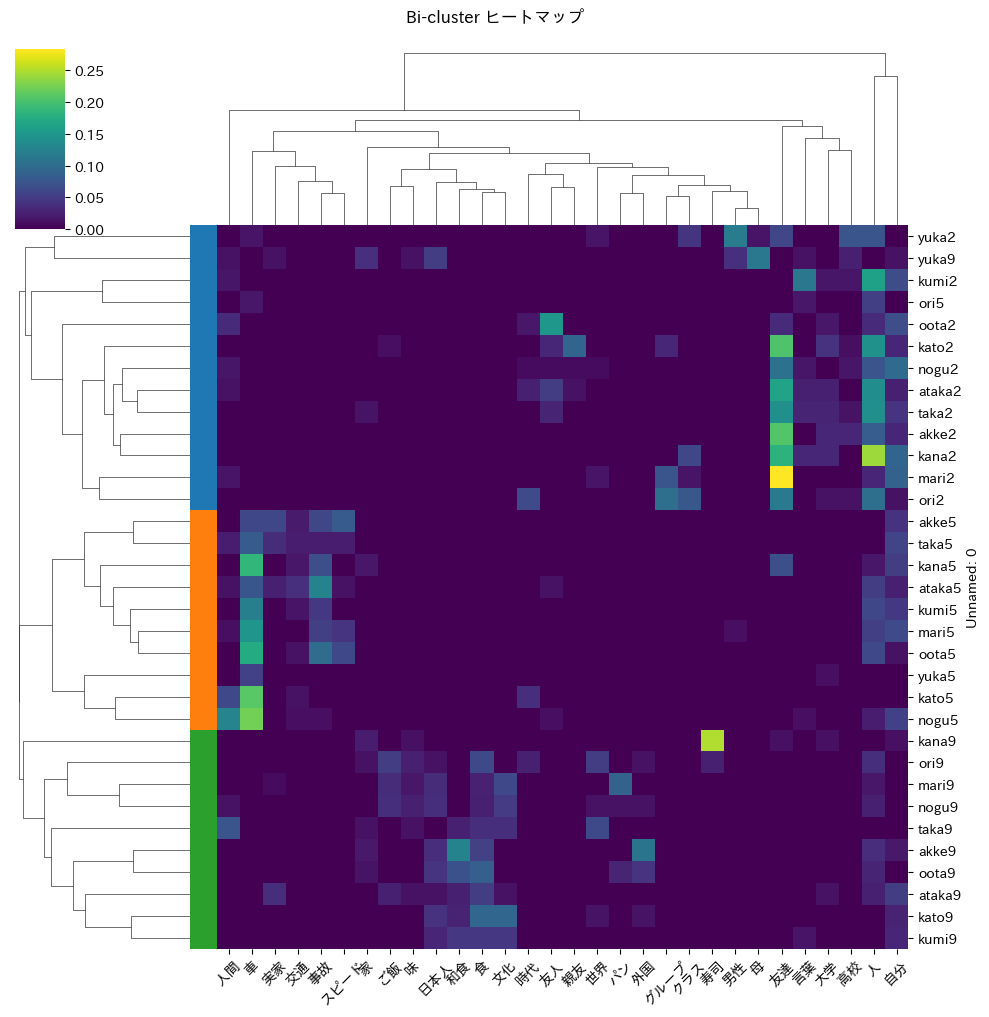

In [2]:
# ============================================================
# 階層的クラスタリング + bi-cluster ヒートマップ（完全版・修正版）
# 第1列をラベルとして使用（対応分析と同じ）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import to_hex
from scipy.spatial.distance import pdist  # 明示的にインポート（jensenshannon用）

# ------------------------------------------------------------
# 1. パラメータ設定
# ------------------------------------------------------------
n_clusters = 3                     # 行クラスタ数
max_columns = 30                 # ★ 先頭から何列使うか（None なら全列）

# 行クラスタリング設定
row_linkage_method = "complete" # "average"      # ★ 修正:  "ward"
row_distance_metric = "jensenshannon"

# 列クラスタリング設定
col_linkage_method = "average"
col_distance_metric = "canberra"

# ------------------------------------------------------------
# 2. データ読み込み
# ------------------------------------------------------------
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding='shift-jis')

# ------------------------------------------------------------
# 3. 第1列をラベルとして使用（対応分析と同じ）
# ------------------------------------------------------------
X = d1.iloc[:, 1:].astype(float)  # ★ 追加: 数値変換
X.index = d1.iloc[:, 0]

# --- 行単位の相対頻度 ---
X_numeric = X.fillna(0).div(X.sum(axis=1), axis=0)  # ★ 追加: 欠損値処理

# ------------------------------------------------------------
# 4. 列数が多い場合 → 先頭 max_columns 列だけ使用
# ------------------------------------------------------------
if max_columns is not None and X_numeric.shape[1] > max_columns:
    X_numeric = X_numeric.iloc[:, :max_columns]

# ------------------------------------------------------------
# 5. 行クラスタリング
# ------------------------------------------------------------
Z = linkage(X_numeric, method=row_linkage_method, metric=row_distance_metric)

# 以降のコードは変更なし（動作確認済み想定）
# ... (残りのコードをそのまま貼り付け)
# ------------------------------------------------------------
# 5. 標準化（行クラスタリング用）
# ------------------------------------------------------------
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_numeric)

# ------------------------------------------------------------
# 6. 行クラスタリング
# ------------------------------------------------------------
#Z = linkage(X_numeric, method=row_linkage_method, metric=row_distance_metric)

cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
label_to_cluster = dict(zip(X.index, cluster_labels))

unique_clusters = np.unique(cluster_labels)
palette = seaborn_palette = sns.color_palette("tab10", len(unique_clusters))
cluster_color_map = {cid: to_hex(col) for cid, col in zip(unique_clusters, seaborn_palette)}

# ------------------------------------------------------------
# 7. 内部ノードにもクラスタIDを割り当てる
# ------------------------------------------------------------
node_cluster = {}
n_samples = len(X.index)

for i, lbl in enumerate(X.index):
    node_cluster[i] = label_to_cluster[lbl]

for i, (c1, c2, dist, cnt) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    node_id = n_samples + i
    if node_cluster[c1] == node_cluster[c2]:
        node_cluster[node_id] = node_cluster[c1]
    else:
        node_cluster[node_id] = 0

# ------------------------------------------------------------
# 8. 枝の色をクラスタIDに応じて返す関数
# ------------------------------------------------------------
def branch_color_func(node_id: int) -> str:
    cid = node_cluster[node_id]
    if cid == 0:
        return "black"
    return cluster_color_map[cid]

# ------------------------------------------------------------
# 9. クラスタ境界の高さ（cut line）
# ------------------------------------------------------------
threshold = Z[-(n_clusters - 1), 2]

# ------------------------------------------------------------
# 10. 樹形図の描画（枝＋ラベル色）
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ddata = dendrogram(
    Z,
    labels=X.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=branch_color_func,
)

ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    text = lbl.get_text()
    cid = label_to_cluster[text]
    lbl.set_color(cluster_color_map[cid])

plt.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.2)

plt.title(f"階層的クラスタリング樹形図（n_clusters = {n_clusters}）")
plt.xlabel("ドキュメント")
plt.ylabel("距離")
plt.tight_layout()
plt.show()

# ============================================================
# 11. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

# ============================================================
# 11. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

row_colors = [cluster_color_map[label_to_cluster[idx]] for idx in X.index]

g = sns.clustermap(
    X_numeric,
    method=row_linkage_method,
    metric=row_distance_metric,
    row_cluster=True,
    col_cluster=True,
    col_linkage=linkage(X_numeric.T, method=col_linkage_method, metric=col_distance_metric),
    row_colors=row_colors,
    cmap="viridis",
    figsize=(10, 10)
)

# ★ ここを 45 度に変更
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45)

# 行ラベルはそのまま（0 度）
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle("Bi-cluster ヒートマップ", y=1.02)
plt.show()


C:\Users\mzjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\mzjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\mzjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


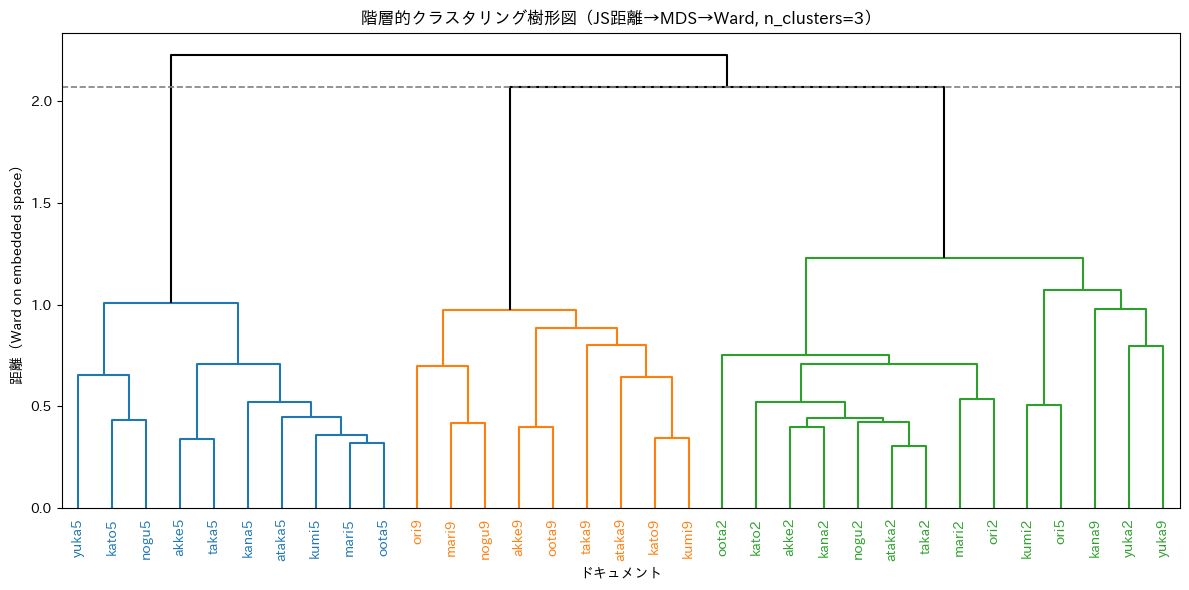

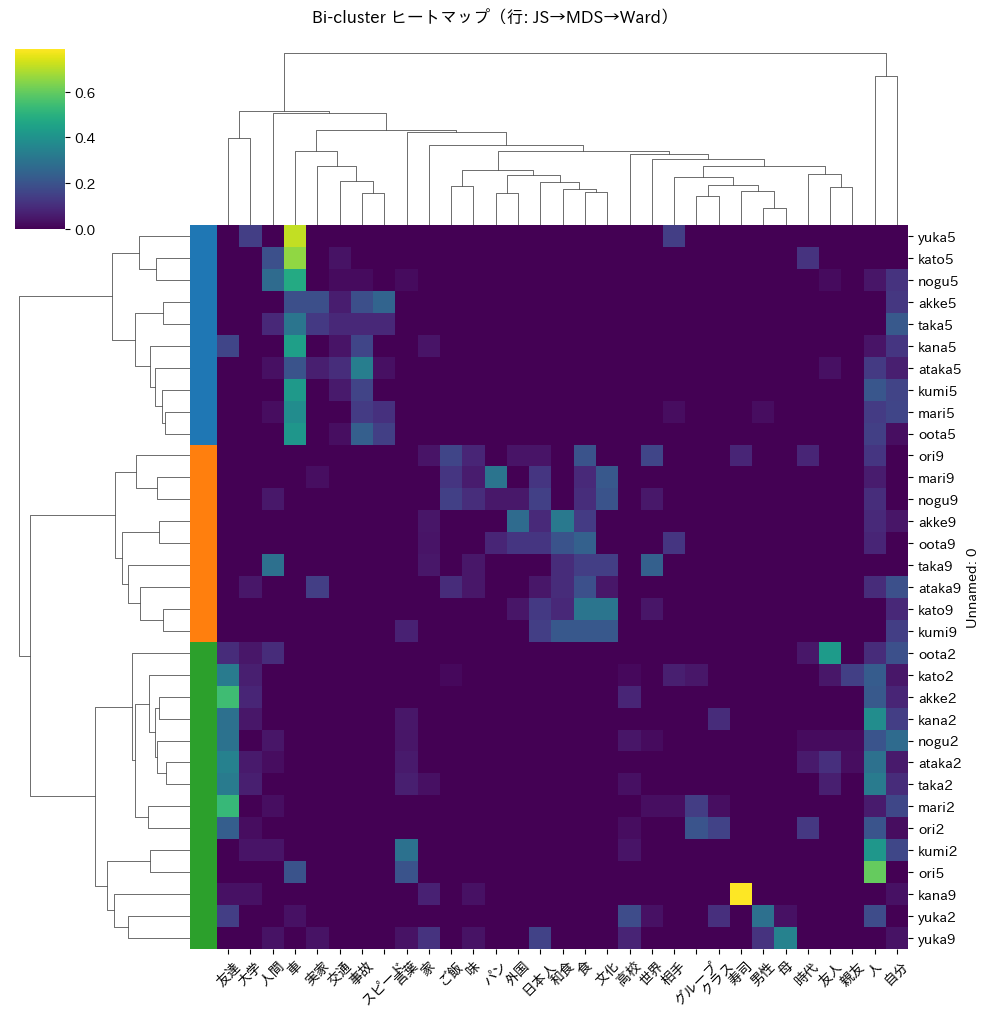

In [8]:
# ============================================================
# 階層的クラスタリング + bi-cluster ヒートマップ（アップグレード版）
# - 第1列をラベルとして使用
# - 行距離: Jensen-Shannon
# - 行linkage: Ward（※JS距離をMDSでユークリッド空間に埋め込み→Ward）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.colors import to_hex

from scipy.spatial.distance import pdist, squareform, jensenshannon
from sklearn.manifold import MDS

# ------------------------------------------------------------
# 1. パラメータ設定
# ------------------------------------------------------------
n_clusters = 3
max_columns = 31  # Noneなら全列

# 行クラスタリング設定（ユーザ要望）
row_distance_metric = "jensenshannon"
row_linkage_method = "ward"  # WardはEuclidean前提 → MDS埋め込み経由で適用

# 列クラスタリング設定（元コード踏襲）
col_linkage_method = "average"
col_distance_metric = "canberra"

# MDS設定（JS距離→Euclidean空間へ）
mds_n_components = max_columns-1        # 次元（大きいほど距離を保持しやすいが過学習/計算コスト増）
mds_random_state = 0

# ------------------------------------------------------------
# 2. データ読み込み
# ------------------------------------------------------------
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding="shift-jis")


# ------------------------------------------------------------
# 3. 第1列をラベルとして使用
# ------------------------------------------------------------
X = d1.iloc[:, 1:].astype(float)
X.index = d1.iloc[:, 0]

row_sums = X_numeric.sum(axis=1)
# 行和が0の行があると正規化できないので除外（または微小値足しでもOK）
nonzero_mask = row_sums > 0
if not nonzero_mask.all():
    print("⚠ 行和が0の行があるため除外しました:", X_numeric.index[~nonzero_mask].tolist())
X_numeric = X_numeric.loc[nonzero_mask]

X_numeric = X_numeric.div(X_numeric.sum(axis=1), axis=0)

# ------------------------------------------------------------
# 4. 列数が多い場合 → 先頭 max_columns 列だけ使用
# ------------------------------------------------------------
if max_columns is not None and X_numeric.shape[1] > max_columns:
    X_numeric = X_numeric.iloc[:, :max_columns]

# ------------------------------------------------------------
# 5. Jensen–Shannon 距離（行間）を計算
# ------------------------------------------------------------
# pdistに jensenshannon を渡す（scipy.spatial.distance.jensenshannon）
# baseは任意。距離の単位が変わるだけで順位関係は概ね維持されます
D_condensed = pdist(X_numeric.values, metric=lambda u, v: jensenshannon(u, v, base=2))
D_square = squareform(D_condensed)

# ------------------------------------------------------------
# 6. JS距離をMDSでEuclidean空間に埋め込み → Ward
# ------------------------------------------------------------
mds = MDS(
    n_components=mds_n_components,
    dissimilarity="precomputed",
    random_state=mds_random_state,
    normalized_stress="auto",
)
X_embed = mds.fit_transform(D_square)

# WardはEuclidean前提なので、埋め込みベクトルに対して実行
Z = linkage(X_embed, method="ward", metric="euclidean")

# ------------------------------------------------------------
# 7. クラスタラベル付与
# ------------------------------------------------------------
cluster_labels = fcluster(Z, t=n_clusters, criterion="maxclust")
label_to_cluster = dict(zip(X_numeric.index, cluster_labels))

unique_clusters = np.unique(cluster_labels)
palette = sns.color_palette("tab10", len(unique_clusters))
cluster_color_map = {cid: to_hex(col) for cid, col in zip(unique_clusters, palette)}

# ------------------------------------------------------------
# 8. 内部ノードにもクラスタIDを割り当てる
# ------------------------------------------------------------
node_cluster = {}
n_samples = len(X_numeric.index)

for i, lbl in enumerate(X_numeric.index):
    node_cluster[i] = label_to_cluster[lbl]

for i, (c1, c2, dist, cnt) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    node_id = n_samples + i
    if node_cluster[c1] == node_cluster[c2]:
        node_cluster[node_id] = node_cluster[c1]
    else:
        node_cluster[node_id] = 0

def branch_color_func(node_id: int) -> str:
    cid = node_cluster[node_id]
    return "black" if cid == 0 else cluster_color_map[cid]

# ------------------------------------------------------------
# 9. クラスタ境界の高さ（cut line）
# ------------------------------------------------------------
threshold = Z[-(n_clusters - 1), 2]

# ------------------------------------------------------------
# 10. 樹形図の描画（枝＋ラベル色）
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ddata = dendrogram(
    Z,
    labels=X_numeric.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=branch_color_func,
)

ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    text = lbl.get_text()
    cid = label_to_cluster[text]
    lbl.set_color(cluster_color_map[cid])

plt.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.2)
plt.title(f"階層的クラスタリング樹形図（JS距離→MDS→Ward, n_clusters={n_clusters}）")
plt.xlabel("ドキュメント")
plt.ylabel("距離（Ward on embedded space）")
plt.tight_layout()
plt.show()

# ============================================================
# 11. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

# row_colors（行のクラスタ色）
row_colors = [cluster_color_map[label_to_cluster[idx]] for idx in X_numeric.index]

# 列linkage（元コードのまま：canberra + average）
Z_col = linkage(X_numeric.T, method=col_linkage_method, metric=col_distance_metric)

# clustermapに row_linkage を直接渡す（= JS→MDS→Ward結果をそのまま使用）
g = sns.clustermap(
    X_numeric,
    row_linkage=Z,            # ←ここが重要（seabornに再計算させない）
    col_linkage=Z_col,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    cmap="viridis",
    figsize=(10, 10),
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle("Bi-cluster ヒートマップ（行: JS→MDS→Ward）", y=1.02)
plt.show()


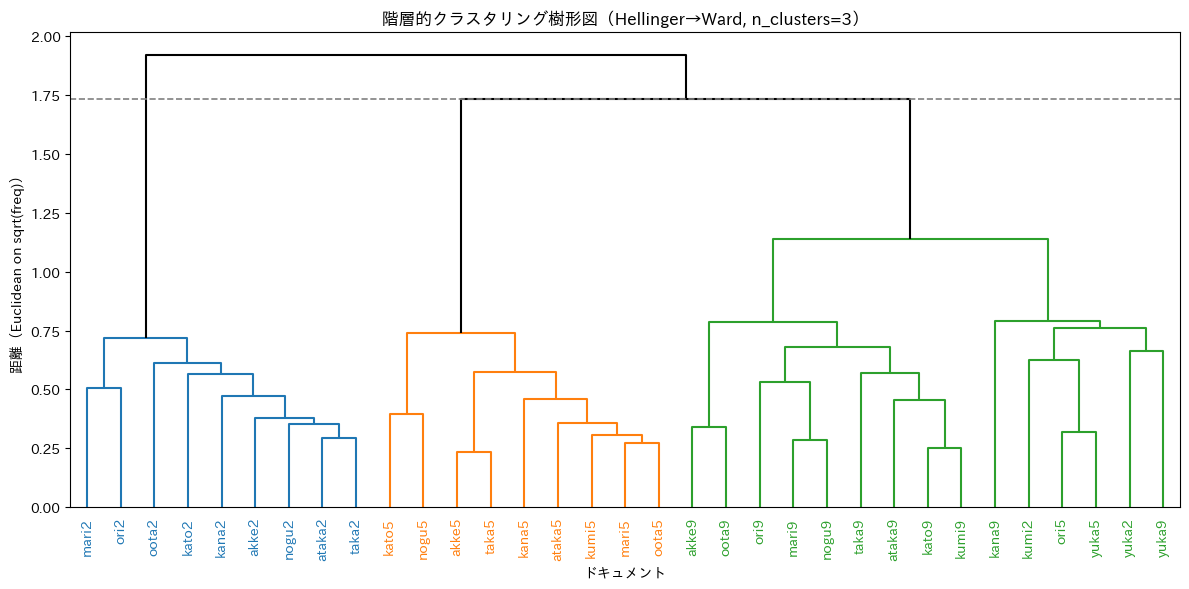

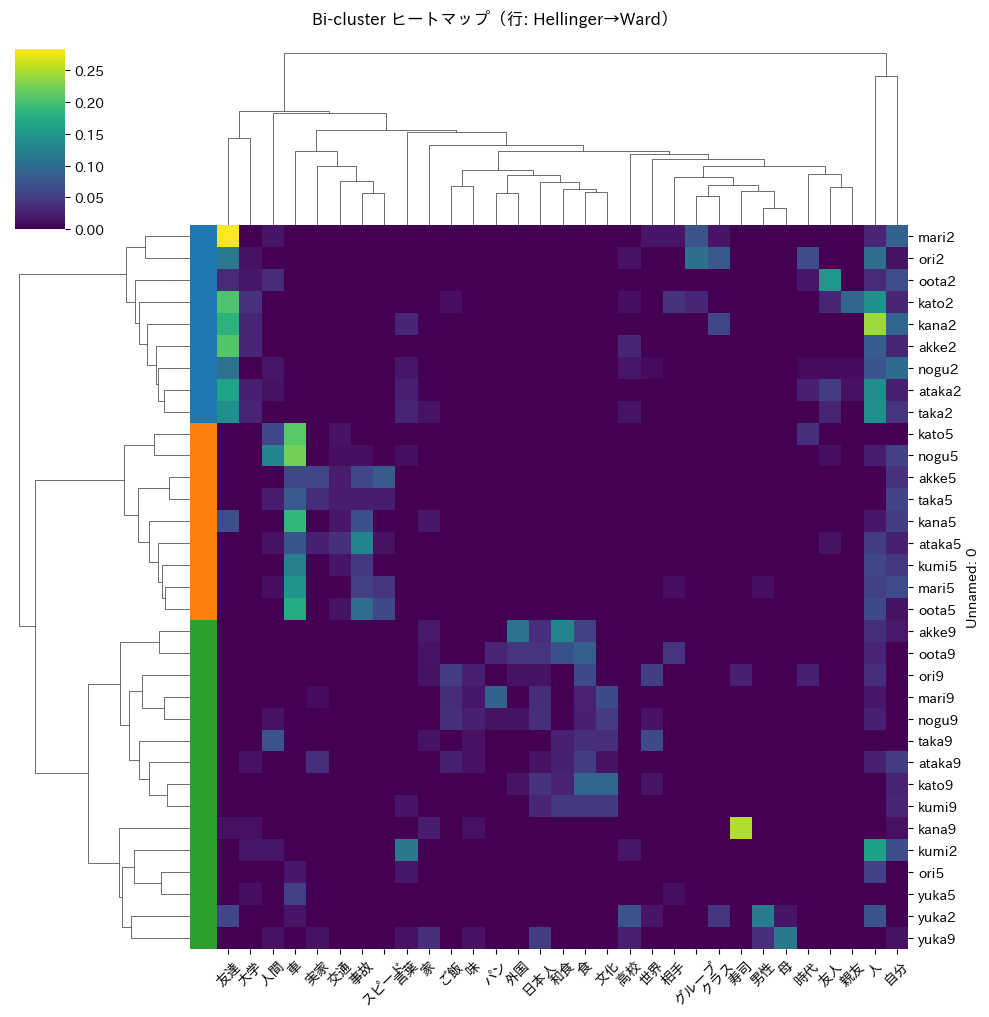

In [7]:
# ============================================================
# 階層的クラスタリング + bi-cluster ヒートマップ（完全版）
# - 第1列をラベルとして使用
# - 行：相対頻度 → Hellinger変換（sqrt） → Ward（Euclidean）
#   ※ Hellinger距離は「確率分布p,qに対して sqrt(p),sqrt(q) のユークリッド距離」
# - 列：canberra + average（元コード踏襲）
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.colors import to_hex
from scipy.spatial.distance import pdist

def hellinger(u, v):
    return np.linalg.norm(np.sqrt(u) - np.sqrt(v)) / np.sqrt(2)
# ------------------------------------------------------------
# 1. パラメータ設定
# ------------------------------------------------------------
n_clusters = 3           # 行クラスタ数
max_columns = 31        # 先頭から何列使うか（Noneなら全列）

# 行クラスタリング（要望）
row_linkage_method = "ward"     # ward は Euclidean 前提
# row_distance_metric は ward では指定しない（常にEuclidean）

# 列クラスタリング（元コード踏襲）
col_linkage_method = "average"
col_distance_metric = "canberra"

# ------------------------------------------------------------
# 2. データ読み込み
# ------------------------------------------------------------
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding="shift-jis")

# ------------------------------------------------------------
# 3. 第1列をラベルとして使用
# ------------------------------------------------------------
X = d1.iloc[:, 1:].astype(float)
X.index = d1.iloc[:, 0]

# ------------------------------------------------------------
# 4. 行単位の相対頻度（欠損→0、行和=0は除外）
# ------------------------------------------------------------
X_numeric = X.fillna(0)

row_sums = X_numeric.sum(axis=1)
nonzero_mask = row_sums > 0
if not nonzero_mask.all():
    print("⚠ 行和が0の行があるため除外しました:", X_numeric.index[~nonzero_mask].tolist())
X_numeric = X_numeric.loc[nonzero_mask]

X_numeric = X_numeric.div(X_numeric.sum(axis=1), axis=0)


# ------------------------------------------------------------
# 5. 列数が多い場合 → 先頭 max_columns 列だけ使用
# ------------------------------------------------------------
if max_columns is not None and X_numeric.shape[1] > max_columns:
    X_numeric = X_numeric.iloc[:, :max_columns]

# ------------------------------------------------------------
# 6. Hellinger変換（sqrt） → Wardクラスタリング
#    Hellinger距離(p,q) = (1/sqrt(2)) * ||sqrt(p)-sqrt(q)||_2
#    ※ 定数(1/sqrt(2))はクラスタリングの順序に影響しないので省略可
# ------------------------------------------------------------
X_hell = np.sqrt(X_numeric) 
# Ward はユークリッド距離前提なので metric は指定しない
Z = linkage(X_hell, method=row_linkage_method)

# または次の自作のhellinger距離関数
# row_distance_metric = pdist(X_numeric.values, metric=hellinger)
# Z = linkage(row_distance_metric, method=row_linkage_method)

# ------------------------------------------------------------
# 7. クラスタラベル付与
# ------------------------------------------------------------
cluster_labels = fcluster(Z, t=n_clusters, criterion="maxclust")
label_to_cluster = dict(zip(X_numeric.index, cluster_labels))

unique_clusters = np.unique(cluster_labels)
palette = sns.color_palette("tab10", len(unique_clusters))
cluster_color_map = {cid: to_hex(col) for cid, col in zip(unique_clusters, palette)}

# ------------------------------------------------------------
# 8. 内部ノードにもクラスタIDを割り当てる
# ------------------------------------------------------------
node_cluster = {}
n_samples = len(X_numeric.index)

for i, lbl in enumerate(X_numeric.index):
    node_cluster[i] = label_to_cluster[lbl]

for i, (c1, c2, dist, cnt) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    node_id = n_samples + i
    if node_cluster[c1] == node_cluster[c2]:
        node_cluster[node_id] = node_cluster[c1]
    else:
        node_cluster[node_id] = 0

# ------------------------------------------------------------
# 9. 枝の色をクラスタIDに応じて返す関数
# ------------------------------------------------------------
def branch_color_func(node_id: int) -> str:
    cid = node_cluster[node_id]
    if cid == 0:
        return "black"
    return cluster_color_map[cid]

# ------------------------------------------------------------
# 10. クラスタ境界の高さ（cut line）
# ------------------------------------------------------------
threshold = Z[-(n_clusters - 1), 2] if n_clusters > 1 else 0

# ------------------------------------------------------------
# 11. 樹形図の描画（枝＋ラベル色）
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ddata = dendrogram(
    Z,
    labels=X_numeric.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=branch_color_func,
)

ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    text = lbl.get_text()
    cid = label_to_cluster[text]
    lbl.set_color(cluster_color_map[cid])

if n_clusters > 1:
    plt.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.2)

plt.title(f"階層的クラスタリング樹形図（Hellinger→Ward, n_clusters={n_clusters}）")
plt.xlabel("ドキュメント")
plt.ylabel("距離（Euclidean on sqrt(freq)）")
plt.tight_layout()
plt.show()

# ============================================================
# 12. bi-cluster（行×列クラスタリング）ヒートマップ
# ============================================================

# 行の色（クラスタ色）
row_colors = [cluster_color_map[label_to_cluster[idx]] for idx in X_numeric.index]

# 列linkage（元コード踏襲：canberra + average）
Z_col = linkage(X_numeric.T, method=col_linkage_method, metric=col_distance_metric)

# seaborn clustermap：
# - 行は Hellinger→Ward の結果(Z)をそのまま使う（再計算させない）
# - ヒートマップ表示値は「相対頻度（元のX_numeric）」のままにする
g = sns.clustermap(
    X_numeric,
    row_linkage=Z,     # ★ 重要：行クラスタはHellinger→Wardを反映
    col_linkage=Z_col,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    cmap="viridis",
    figsize=(10, 10),
)

# x軸ラベル 45度
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45)
# y軸ラベル 0度
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle("Bi-cluster ヒートマップ（行: Hellinger→Ward）", y=1.02)
plt.show()
